<a href="https://colab.research.google.com/github/larissavaladao/time_series_curuai/blob/main/5.%20parameters_by_period/3.area_TSS_time_series.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import ee
import geemap
import matplotlib.pyplot as plt 
import os
import seaborn as sns

In [ ]:
# Configure matplotlib visualization parameters for consistency across all plots
plt.rcParams['font.size'] = 14  # Base font size
plt.rcParams['axes.labelsize'] = 14  # Axis label font size
plt.rcParams['axes.titlesize'] = 14  # Plot title font size
plt.rcParams['xtick.labelsize'] = 14  # X-axis tick label size
plt.rcParams['ytick.labelsize'] = 14  # Y-axis tick label size
plt.rcParams['legend.fontsize'] = 14  # Legend font size

In [14]:
ee.Authenticate(auth_mode='notebook')
ee.Initialize(project='ee-curuai2')

In [15]:
# from google.colab import drive
# drive.mount('/content/drive')

In [16]:
exp_directory = r"C:\Users\l_v_v\Documents\GitHub\time_series_curuai\datasets\Parameters Time series\Results"

# Time Series Display Function

In [17]:
def prepare_time_series_plot(df, var, title, color_palette=None):
    """
    Create and display a time series plot with predictions and observations.
    
    Parameters:
    - df: DataFrame containing the time series data
    - var: Variable name to plot on y-axis
    - title: Title for the plot and output file
    - color_palette: Color scheme for water periods (default: uses predefined palette)
    """
    
    # Sort dataframe by time to ensure chronological order
    df = df.sort_values(by='time_start')

    # Create figure and axis with appropriate size for visibility
    fig, ax = plt.subplots(figsize=(16, 6))   

    # Plot the variable as a gray line to show overall trend
    ax.plot(df['time_start'], df[var], alpha=0.5,
                color='gray', linestyle='-.', linewidth=1)
    
    # Extract unique water periods and define color palette
    water_periods = sorted(df['water_period'].unique())
    if color_palette is None:
        color_palette = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

    # Map each water period to a specific color
    colors = {period: color_palette[i % len(color_palette)] for i, period in enumerate(water_periods)}

    # Plot observations separately for each water period with distinct colors
    for water_period in water_periods:
        subset = df[df['water_period'] == water_period]
        ax.plot(subset['time_start'], subset[var],
                marker='o', markersize=6, alpha=0.5,
                color=colors[water_period], linestyle='none',
                label=f'{water_period}')

    # Set x-axis label
    ax.set_xlabel('Date')
    
    # Set y-axis label and output directory based on variable type
    if "TSS" in var:
        ax.set_ylabel('TSS (mg/L)')
        directory = os.path.join(exp_directory, "TSS")
    elif "area" in var:
        ax.set_ylabel("Area (km$^2$)")
        directory = os.path.join(exp_directory, "Area")
    else:
        directory = exp_directory
    
    # Set title and legend
    ax.set_title(f"{title} vs Time")
    ax.legend(loc='upper right')

    # Adjust layout and save figure
    plt.tight_layout()
    plt.savefig(os.path.join(directory, f"{title}_time_series.jpg"), dpi=300)
    plt.show()
    plt.close()
    

# Import Image Collections from Earth Engine

In [50]:
# Load the floodplain boundary feature collection from Earth Engine assets
varzea = ee.FeatureCollection('projects/ee-curuai2/assets/varzea_alagavel')

In [51]:
# Load TSS mosaics from Earth Engine and clip to floodplain boundaries
water_mosaics = ee.ImageCollection('projects/ee-curuai2/assets/landsat_water_period/tss_mosaic')\
    .map(lambda img: img.clip(varzea))

# Define a function to extract and add sorting index to images
def insert_sorting_idx(img):
    """Extract numerical index from image ID for sorting purposes"""
    idx = ee.Number.parse(ee.String(img.get('system:index')).slice(4))
    return img.set("idx", idx)

# Apply sorting function and sort images by extracted index
water_mosaics = water_mosaics.map(insert_sorting_idx).sort('idx')

# Display information about the first image in the collection
print(water_mosaics.first().getInfo())


{'type': 'Image', 'bands': [{'id': 'TSS', 'data_type': {'type': 'PixelType', 'precision': 'float'}, 'dimensions': [4220, 2102], 'crs': 'EPSG:32621', 'crs_transform': [30, 0, 599700, 0, -30, -211710]}], 'version': 1769031176179145, 'id': 'projects/ee-curuai2/assets/landsat_water_period/tss_mosaic/tss_0', 'properties': {'idx': 0, 'time_start': '1984-12-24', 'water_period': 'R', 'year': '1984', 'system:footprint': {'type': 'LinearRing', 'coordinates': [[-56.10369364543149, -1.915265776712242], [-56.10369577355884, -1.9152995492666665], [-56.10335527381017, -2.4854729286834942], [-56.10324537778488, -2.48559729084968], [-56.10315191093545, -2.485734367687388], [-56.10311862722599, -2.4857406263502817], [-56.10308483278137, -2.4857427491104156], [-54.964962609853586, -2.4844726086096927], [-54.964838245563556, -2.4843627292230734], [-54.96470110893802, -2.48426930135189], [-54.96469270596578, -2.4842249150774953], [-54.96546519471255, -1.9143205459546146], [-54.965575106665284, -1.914196301

# Calculate Mean TSS Statistics per Image

In [19]:
def TSS_stat_calc(img):
    """
    Calculate statistical measures of TSS (Total Suspended Sediment) within the floodplain.
    
    This function processes a masked TSS classified Landsat image of the Curuai floodplain
    and computes multiple statistical measures (mean, max, min, and standard deviation)
    within the floodplain boundaries. Results are returned as properties of the input image.
    
    Parameters:
    - img: Earth Engine Image with TSS band
    
    Returns:
    - Image with TSS statistics added as properties
    """
    
    # Load the floodplain boundary
    floodplain = ee.FeatureCollection('projects/ee-curuai2/assets/varzea_alagavel')

    # Calculate multiple statistics in a single region reduction
    stats = img.select("TSS").reduceRegion(**{
        'reducer': ee.Reducer.mean().combine(
            reducer2=ee.Reducer.stdDev(), sharedInputs=True).combine(
            reducer2=ee.Reducer.max(), sharedInputs=True).combine(
            reducer2=ee.Reducer.min(), sharedInputs=True),
        'geometry': floodplain.geometry(),
        'scale': 30,  # 30-meter pixel size of Landsat data
        'maxPixels': 1e10
    })

    # Add calculated statistics as image properties
    return img.set({
        'TSS_mean': stats.get('TSS_mean'),
        'TSS_max': stats.get('TSS_max'),
        'TSS_min': stats.get('TSS_min'),
        'TSS_stdDev': stats.get('TSS_stdDev')
    })

In [20]:
# Apply the statistical calculation function to all images in the collection
TSS_cota_stat = water_mosaics.map(TSS_stat_calc)

# Display the total number of images with calculated statistics
display(TSS_cota_stat.size().getInfo())

138

# Transform Earth Engine Data to Pandas DataFrame

In [21]:
# Convert Earth Engine FeatureCollection to Pandas DataFrame
dfArea = ee.data.computeFeatures({
    'expression': ee.FeatureCollection(TSS_cota_stat.map(lambda img: ee.Feature(None, img.toDictionary()))),
    'fileFormat': 'PANDAS_DATAFRAME'
}).drop(columns="geo")

# Convert time column to datetime format for proper time series operations
dfArea['time_start'] = pd.to_datetime(dfArea['time_start'])

# Display the dataframe structure and first rows
dfArea

,TSS_max,TSS_mean,TSS_min,TSS_stdDev,area_km2,band_count,month_init,time_finish,time_start,water_period,year
0,231.388351,48.812000,8.646607,27.405530,1043.404013,6,12,1985-04-09,1984-12-24,R,1984
1,230.723541,26.369015,7.906408,18.243428,1091.495113,6,4,1985-07-09,1985-04-09,HW,1985
2,233.435242,50.619849,8.056080,28.007771,1165.734402,6,12,1988-04-08,1987-12-24,R,1987
3,232.882141,75.235640,9.389283,41.332442,1088.595262,6,9,2013-12-16,2013-09-16,LW,2013
4,216.593796,21.106929,7.899100,11.601760,1554.413956,6,3,2014-06-16,2014-03-16,HW,2014
...,...,...,...,...,...,...,...,...,...,...,...
133,225.852798,23.806894,7.903844,12.717473,1542.015690,6,3,2012-06-16,2012-03-08,HW,2012
134,215.974701,23.173180,7.944693,8.832932,1545.135802,6,6,2012-09-16,2012-06-16,F,2012
135,229.276566,173.043255,10.235375,53.782766,663.304333,6,9,2012-12-16,2012-09-16,LW,2012
136,225.852798,23.219416,7.910933,16.422054,1444.078915,6,3,2013-06-16,2013-03-16,HW,2013


In [ ]:
# Export the complete time series dataframe to a CSV file for future reference and analysis
dfArea.to_csv(os.path.join(exp_directory, 'area_TSS_time_series.csv'))

# Visualize Time Series Data

## Floodplain Area vs Time

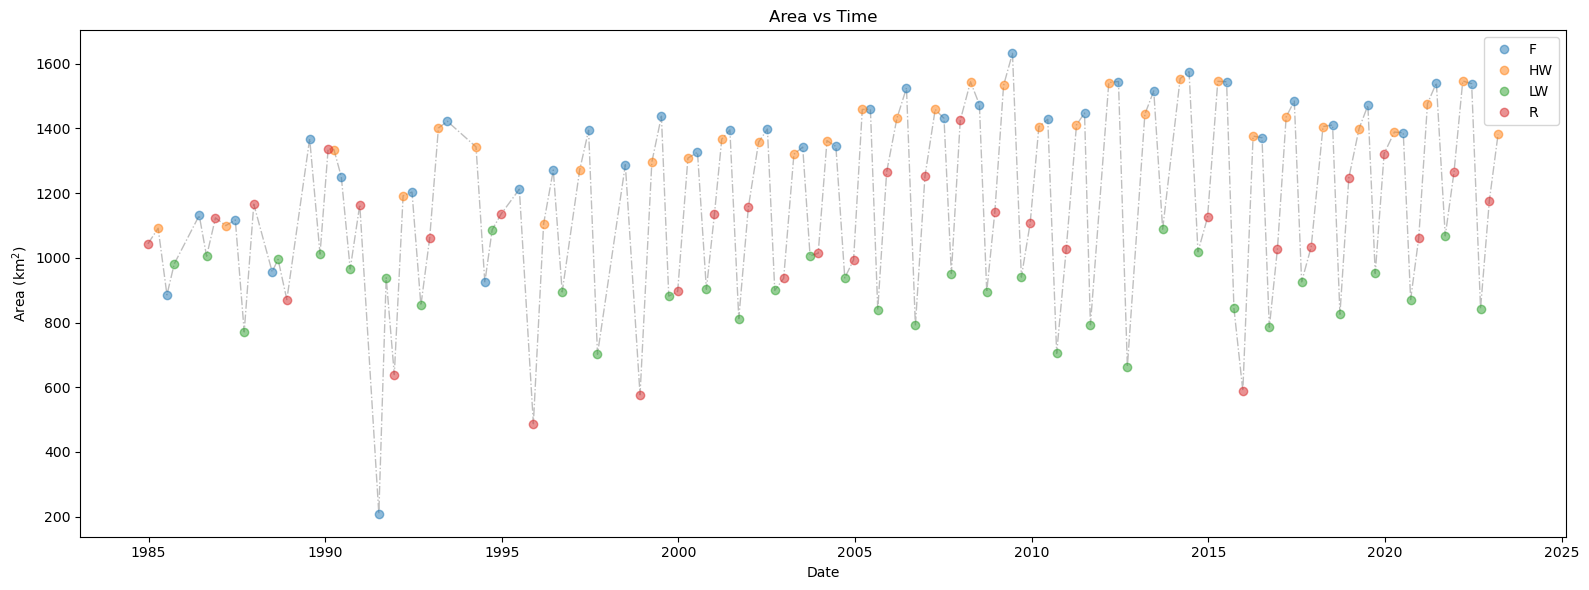

In [22]:
# Create and display time series plot for floodplain area over time
prepare_time_series_plot(dfArea, 'area_km2', "Area")

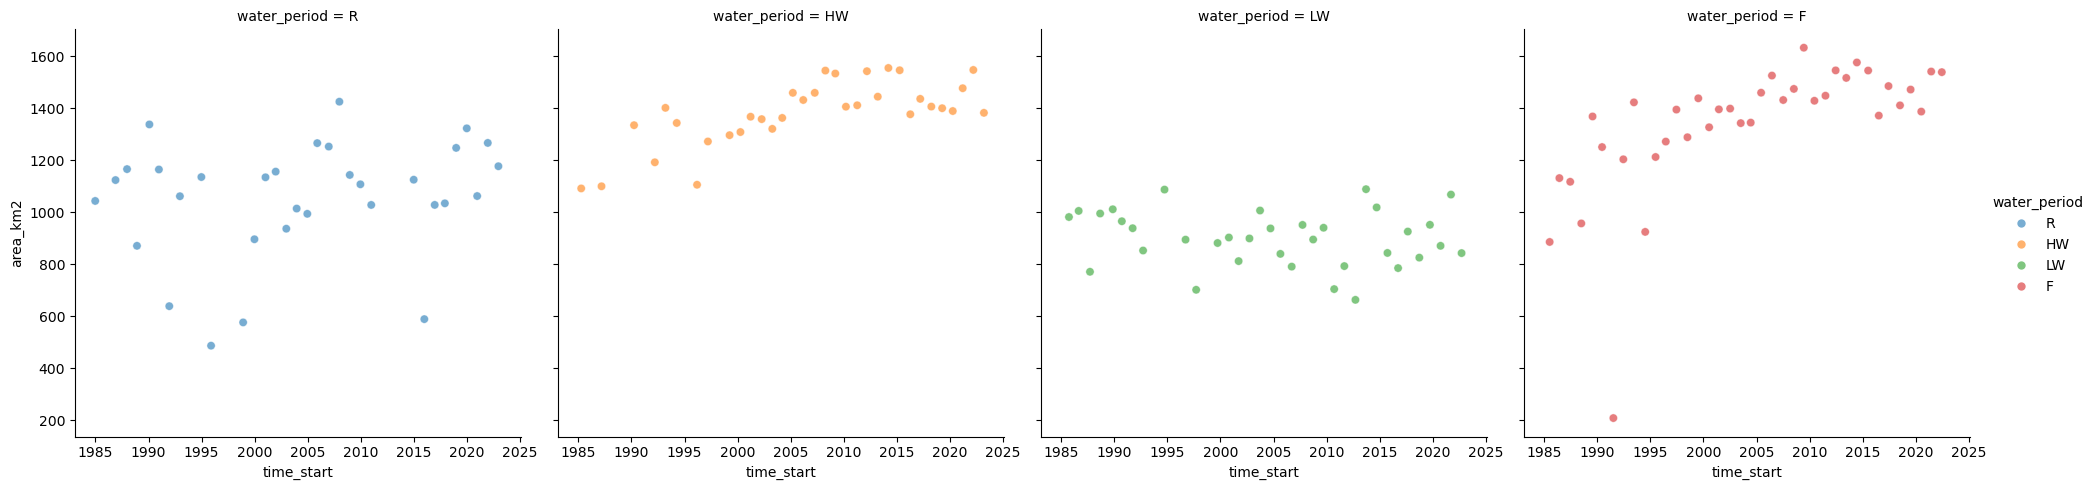

In [23]:
# Create separate scatter plots for area vs time for each water period
sns.relplot(data=dfArea, x='time_start', y='area_km2', alpha=.6, hue='water_period', col='water_period')

## Area vs TSS (Total Suspended Sediment)

### Mean TSS Concentration

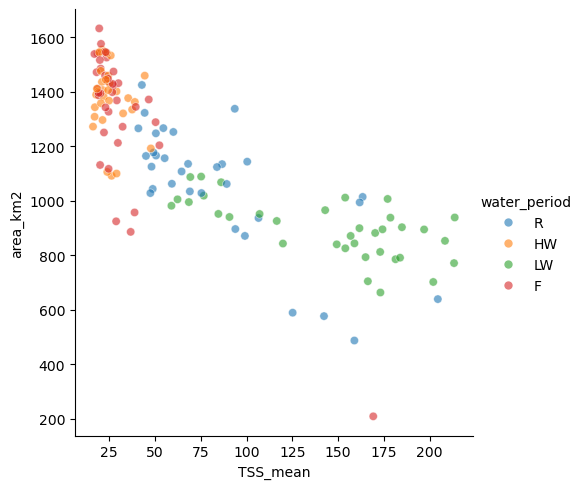

In [24]:
# Create scatter plot showing relationship between mean TSS and floodplain area, colored by water period
sns.relplot(data=dfArea, x='TSS_mean', y='area_km2', alpha=.6, hue='water_period')

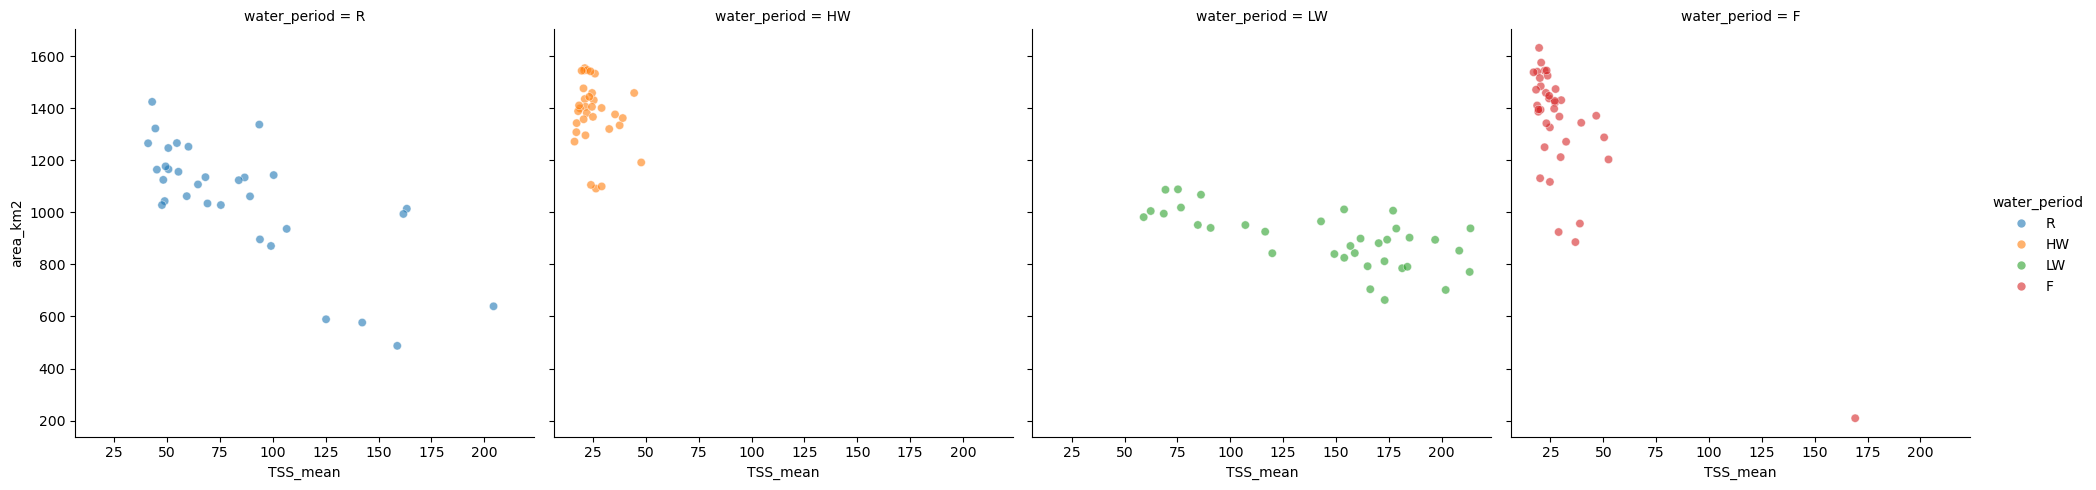

In [25]:
# Create separate scatter plots for mean TSS vs area for each water period
sns.relplot(data=dfArea, x='TSS_mean', y='area_km2', alpha=.6, hue='water_period', col='water_period')

### Maximum TSS Concentration

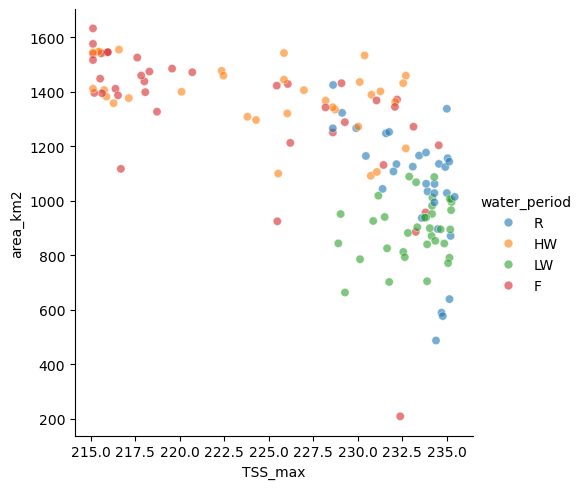

In [26]:
# Create scatter plot showing relationship between maximum TSS and floodplain area
sns.relplot(data=dfArea, x='TSS_max', y='area_km2', alpha=.6, hue='water_period')

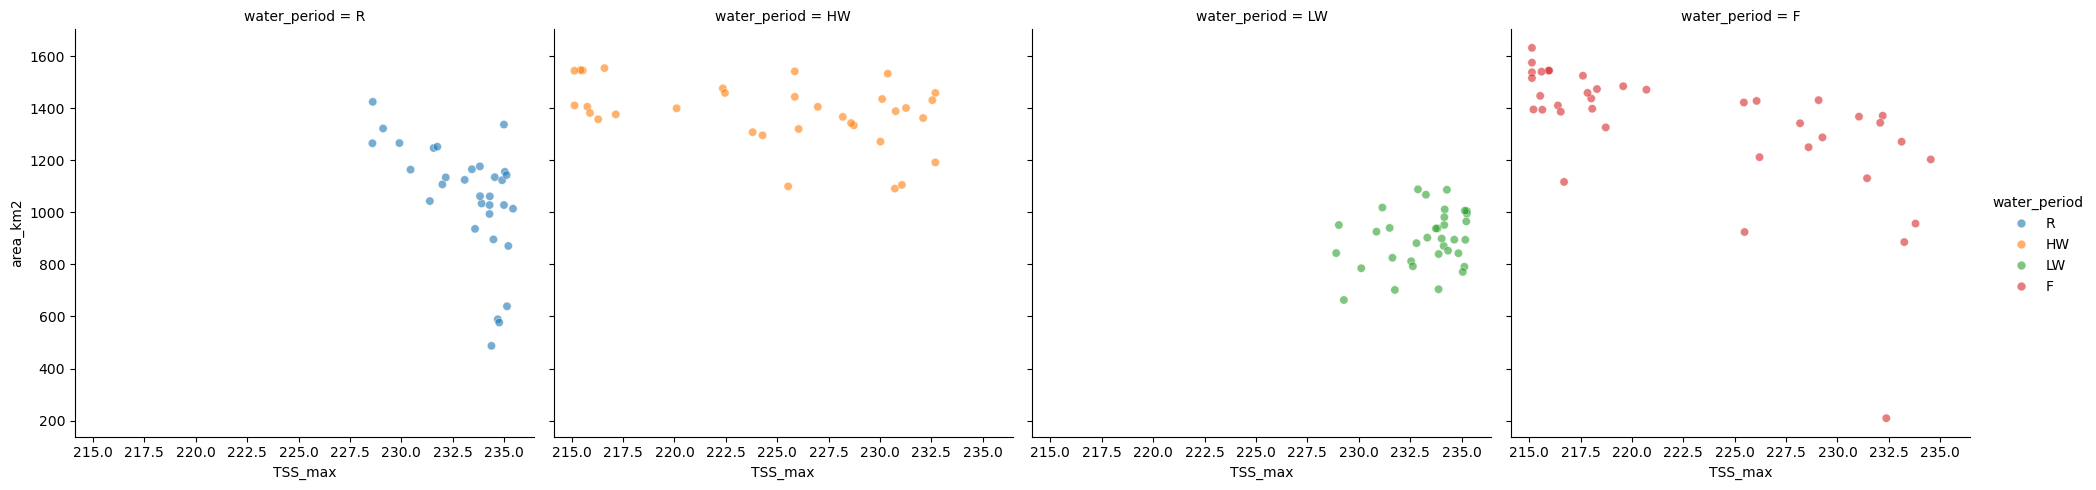

In [27]:
# Create separate scatter plots for maximum TSS vs area for each water period
sns.relplot(data=dfArea, x='TSS_max', y='area_km2', alpha=.6, hue='water_period', col='water_period')

### Minimum TSS Concentration

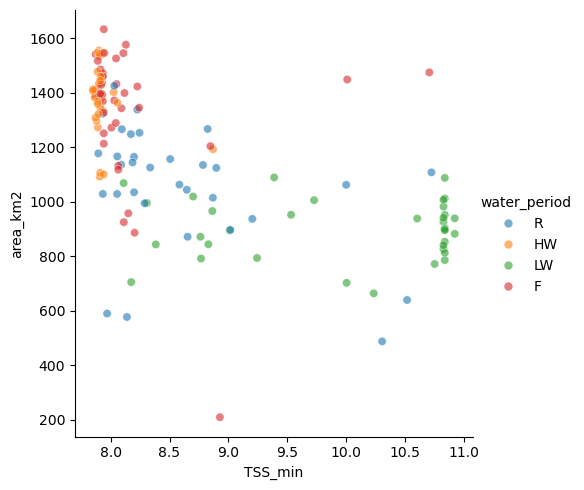

In [28]:
# Create scatter plot showing relationship between minimum TSS and floodplain area
sns.relplot(data=dfArea, x='TSS_min', y='area_km2', alpha=.6, hue='water_period')

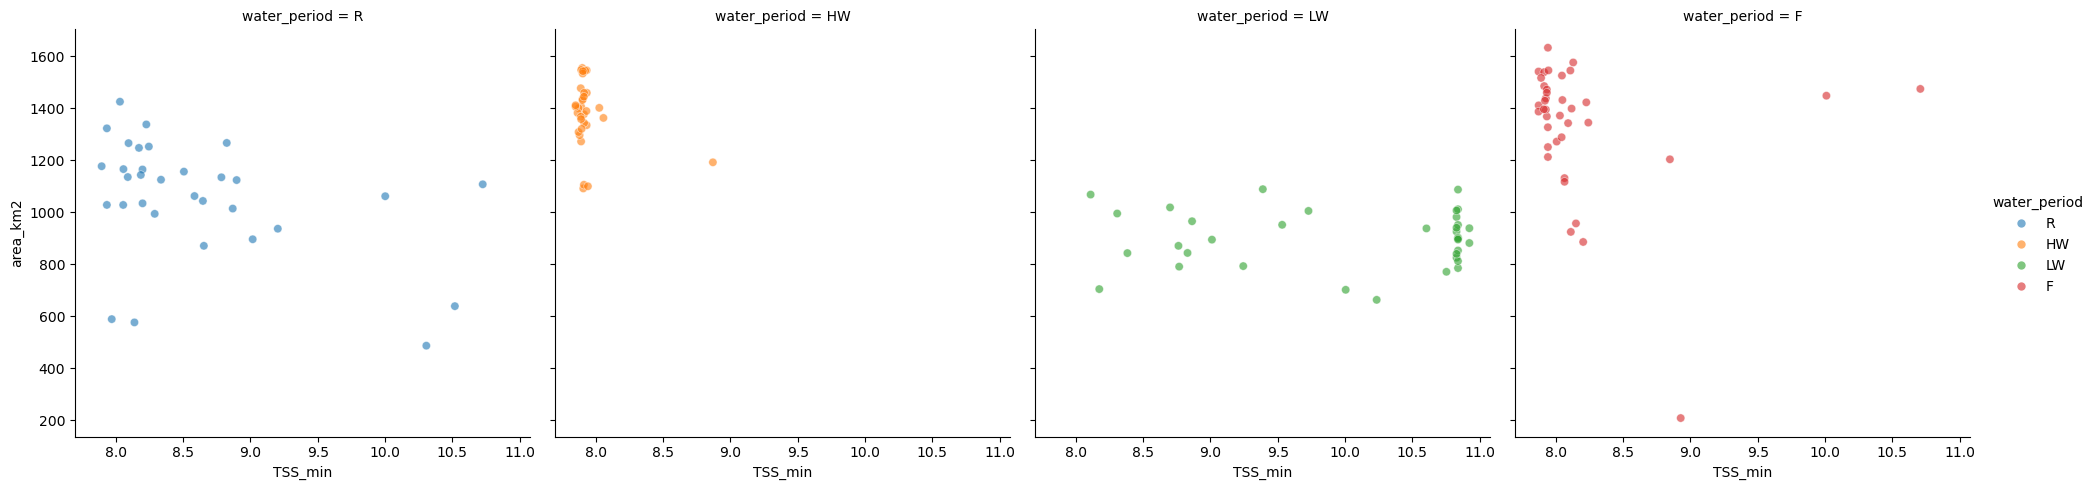

In [29]:
# Create separate scatter plots for minimum TSS vs area for each water period
sns.relplot(data=dfArea, x='TSS_min', y='area_km2', alpha=.6, hue='water_period', col='water_period')

### Standard Deviation of TSS

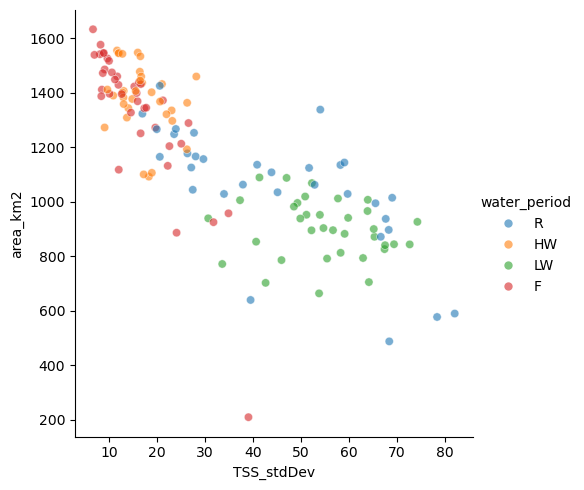

In [30]:
# Create scatter plot showing relationship between TSS variability (standard deviation) and floodplain area
sns.relplot(data=dfArea, x='TSS_stdDev', y='area_km2', alpha=.6, hue='water_period')

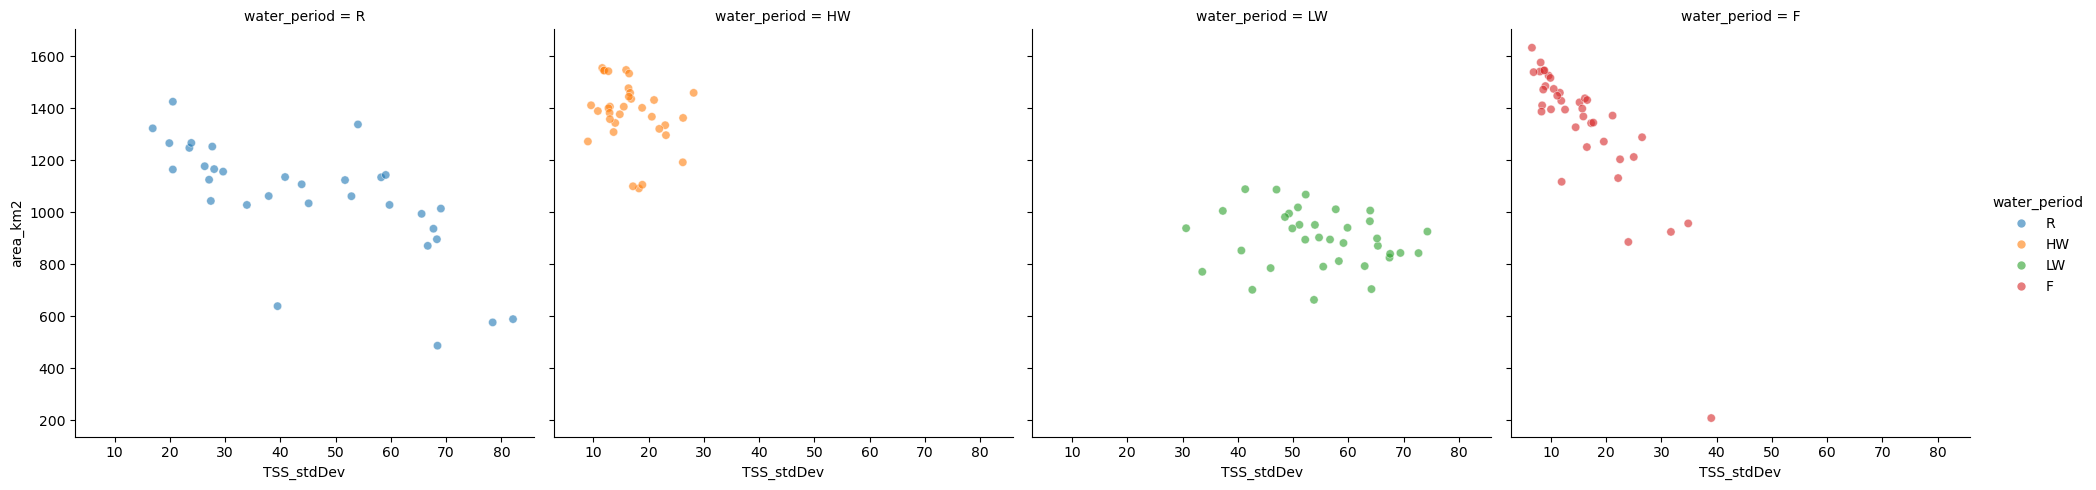

In [31]:
# Create separate scatter plots for TSS standard deviation vs area for each water period
sns.relplot(data=dfArea, x='TSS_stdDev', y='area_km2', alpha=.6, hue='water_period', col='water_period')

## TSS Metrics vs Time

### Mean TSS Concentration Over Time

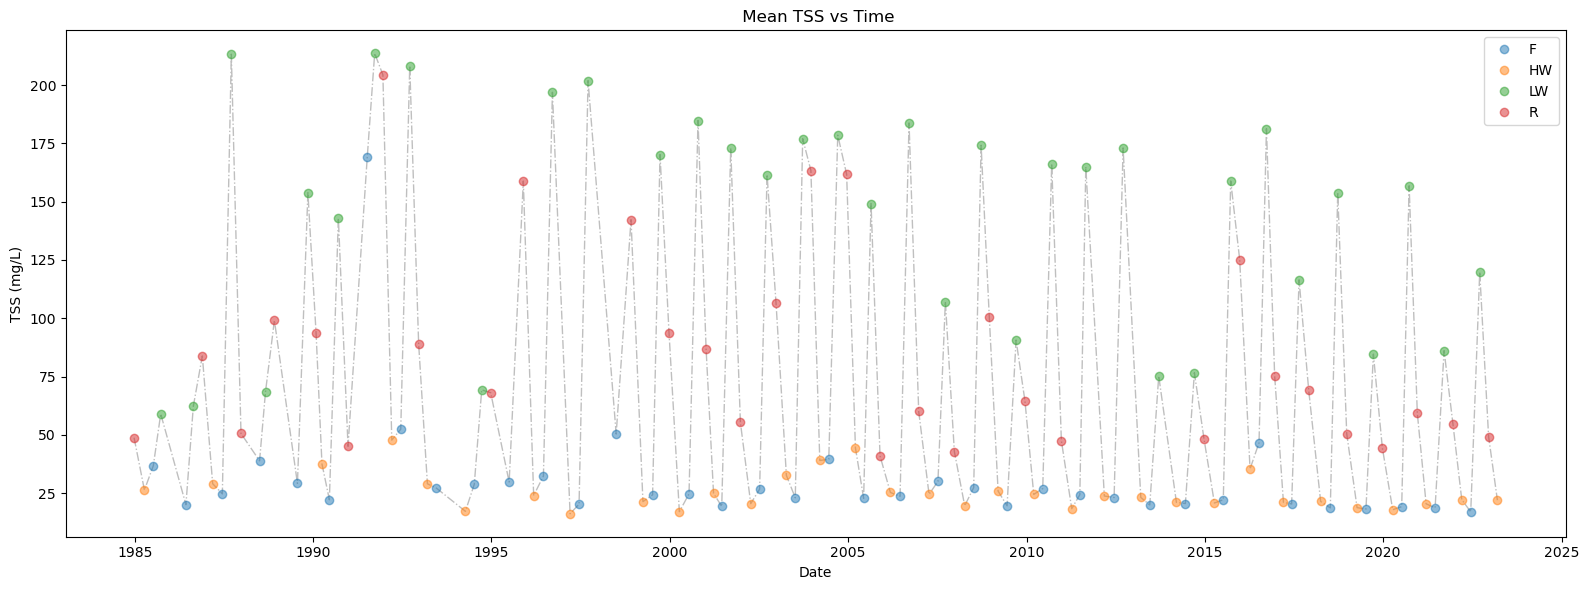

In [32]:
# Create and display time series plot for mean TSS concentration over time
prepare_time_series_plot(dfArea, 'TSS_mean', "Mean TSS")

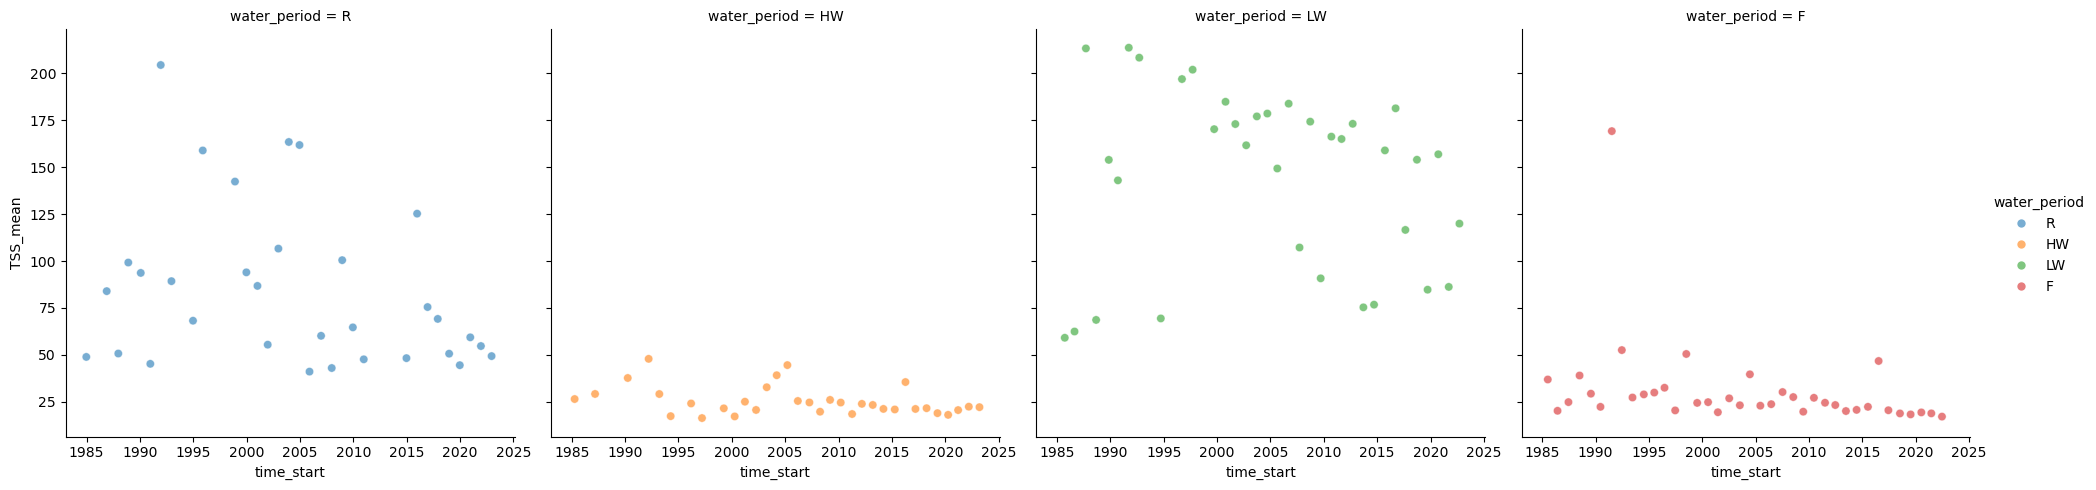

In [33]:
# Create separate time series plots for mean TSS for each water period
sns.relplot(data=dfArea, x='time_start', y='TSS_mean', alpha=.6, hue='water_period', col='water_period')

### Maximum TSS Concentration Over Time

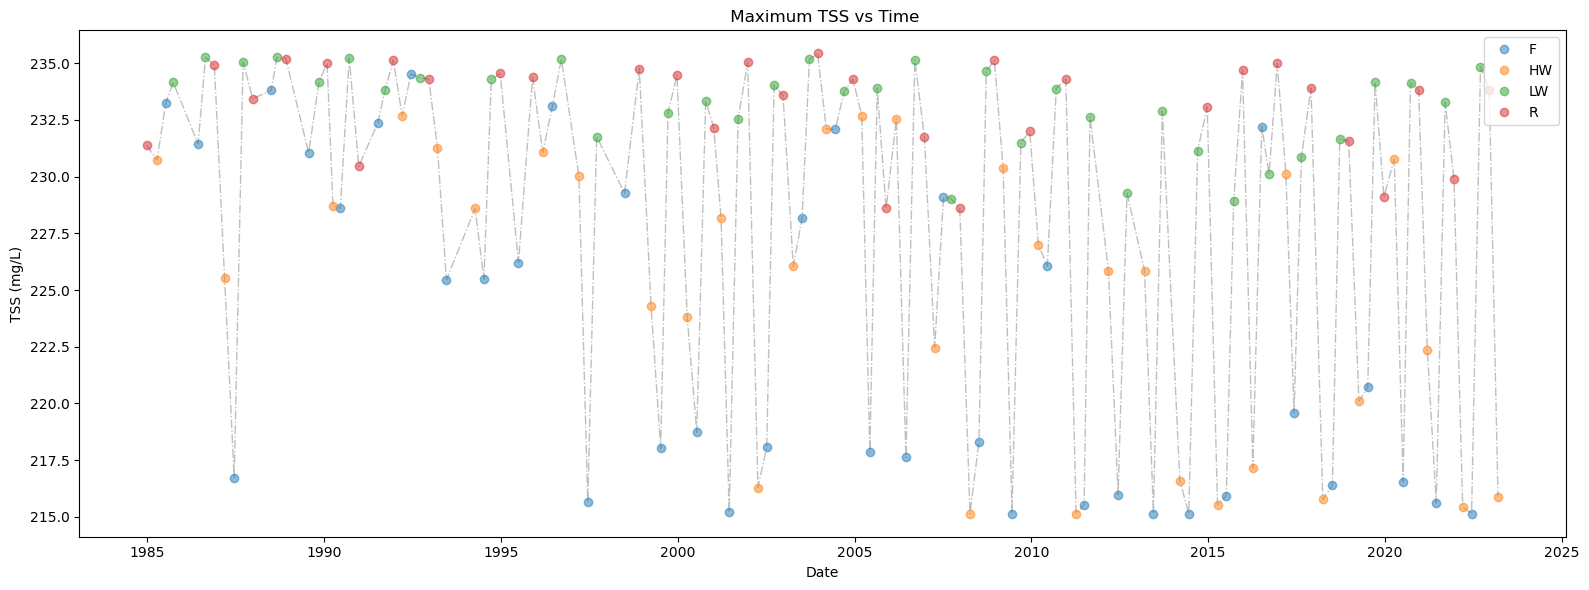

In [34]:
# Create and display time series plot for maximum TSS concentration over time
prepare_time_series_plot(dfArea, 'TSS_max', "Maximum TSS")

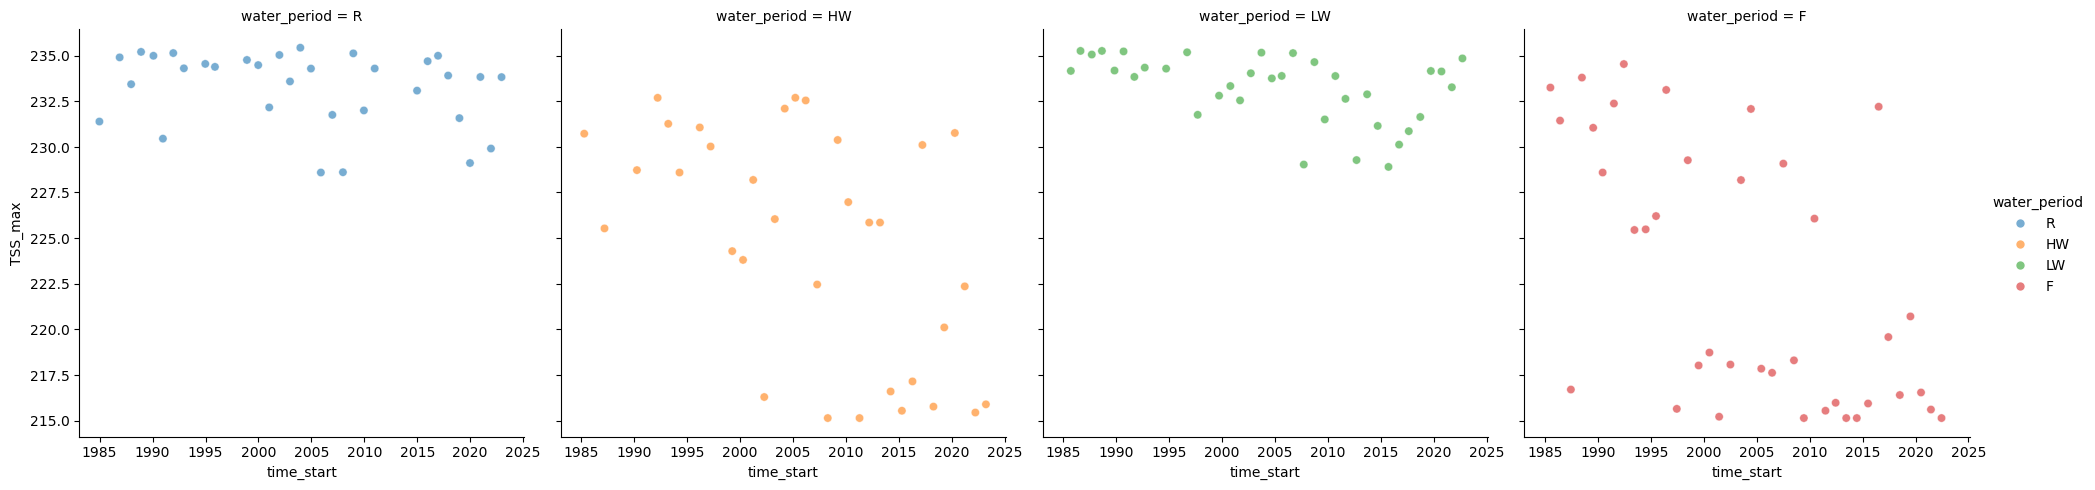

In [35]:
# Create separate time series plots for maximum TSS for each water period
sns.relplot(data=dfArea, x='time_start', y='TSS_max', alpha=.6, hue='water_period', col='water_period')

### Minimum TSS Concentration Over Time

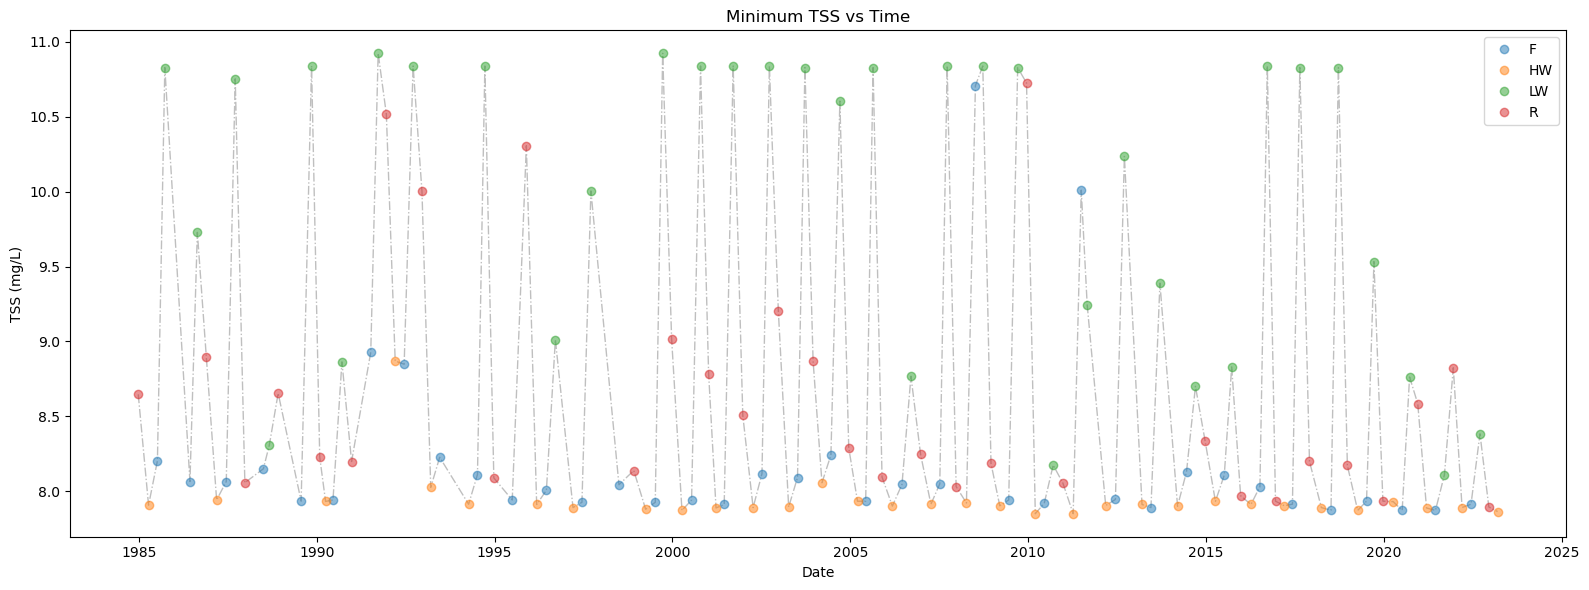

In [36]:
# Create and display time series plot for minimum TSS concentration over time
prepare_time_series_plot(dfArea, 'TSS_min', "Minimum TSS")

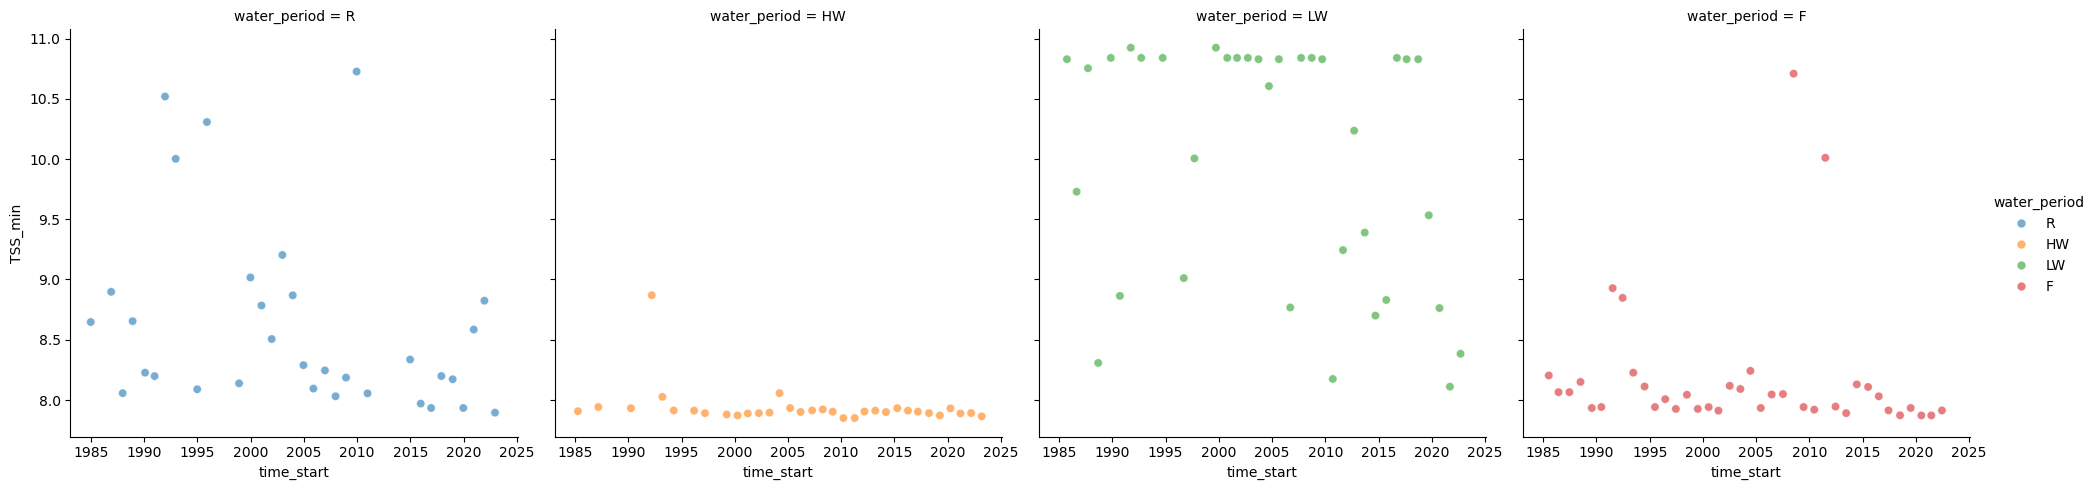

In [37]:
# Create separate time series plots for minimum TSS for each water period
sns.relplot(data=dfArea, x='time_start', y='TSS_min', alpha=.6, hue='water_period', col='water_period')

### TSS Variability (Standard Deviation) Over Time

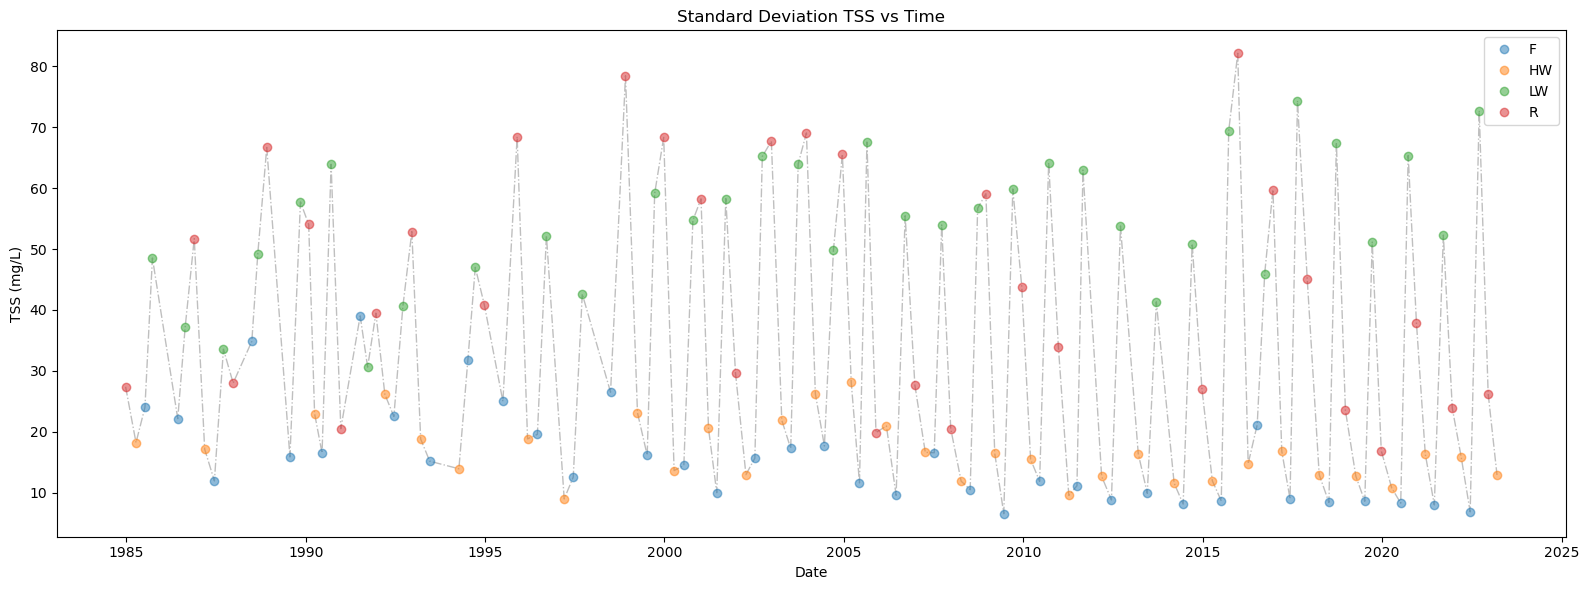

In [38]:
# Create and display time series plot for TSS standard deviation over time
prepare_time_series_plot(dfArea, 'TSS_stdDev', "Standard Deviation TSS")

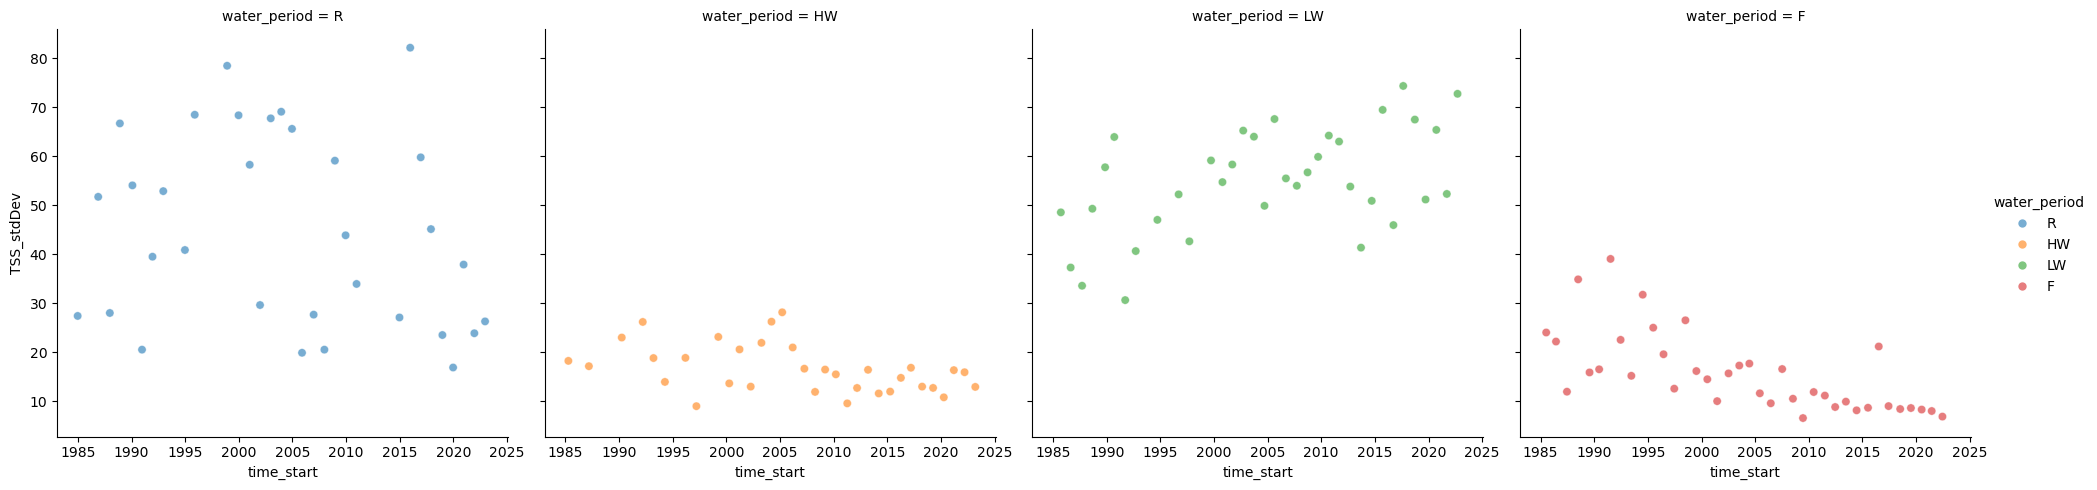

In [39]:
# Create separate time series plots for TSS standard deviation for each water period
sns.relplot(data=dfArea, x='time_start', y='TSS_stdDev', alpha=.6, hue='water_period', col='water_period')

# Data Summary and Distribution Analysis

In [40]:
# Display statistical summary of the dataframe (mean, std, min, max, quartiles)
dfArea.describe()

,TSS_max,TSS_mean,TSS_min,TSS_stdDev,area_km2,band_count,time_start
count,138.000000,138.000000,138.000000,138.000000,138.000000,138.0,138
mean,228.313265,70.521853,8.680911,32.580458,1170.369033,6.0,2004-12-06 22:05:13.043478272
min,215.136505,16.229499,7.849281,6.579396,209.001933,6.0,1984-12-24 00:00:00
25%,224.576111,23.676090,7.925432,15.272184,953.023024,6.0,1995-08-06 06:00:00
50%,231.207642,44.792144,8.110365,24.519615,1184.348927,6.0,2005-04-27 00:00:00
75%,233.887894,100.059797,8.920142,52.071880,1400.833415,6.0,2014-08-24 00:00:00
max,235.435547,213.592362,10.924068,82.104351,1632.260380,6.0,2023-03-16 00:00:00
std,6.947424,59.487890,1.064068,21.020314,275.301030,0.0,NaN


<Axes: >

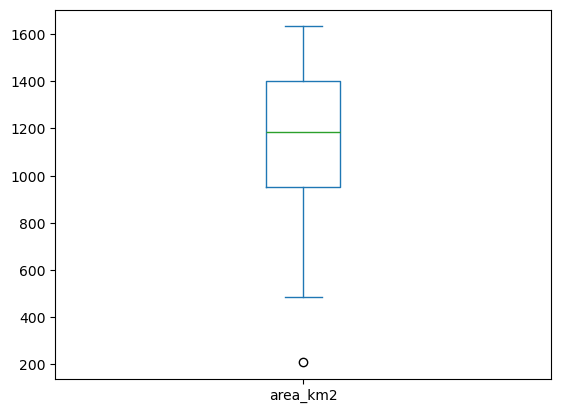

In [41]:
# Create box plot to visualize the distribution and outliers of floodplain area values
dfArea['area_km2'].plot.box()

<Axes: >

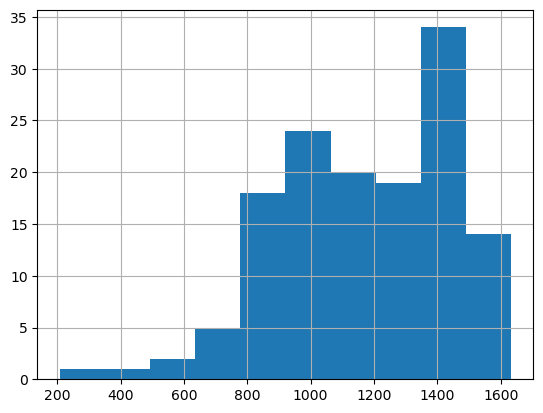

In [42]:
# Create histogram to visualize the distribution of floodplain area values
dfArea['area_km2'].hist()

<Axes: >

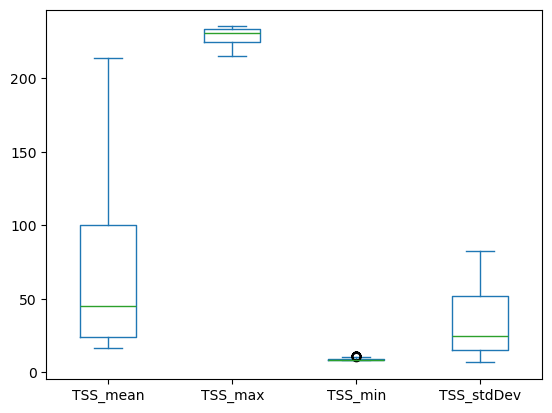

In [43]:
# Create box plots for all TSS statistics to visualize distributions and detect outliers
dfArea[['TSS_mean', 'TSS_max', 'TSS_min', 'TSS_stdDev']].plot.box()

array([[<Axes: title={'center': 'TSS_mean'}>,
        <Axes: title={'center': 'TSS_max'}>],
       [<Axes: title={'center': 'TSS_min'}>,
        <Axes: title={'center': 'TSS_stdDev'}>]], dtype=object)

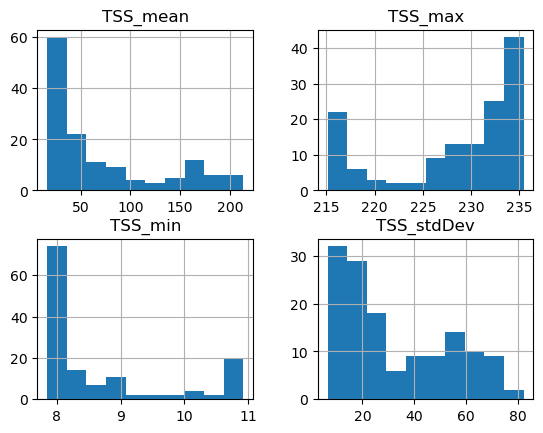

In [44]:
# Create histograms for all TSS statistics to visualize their frequency distributions
dfArea[['TSS_mean', 'TSS_max', 'TSS_min', 'TSS_stdDev']].hist()

# Create Animated Visualizations (GIF Videos)

In [52]:
# Load the water period mosaics collection for animation generation
colecao = ee.ImageCollection('projects/ee-curuai2/assets/landsat_water_period/water_period_mosaics').sort("system:time_start")


In [ ]:
# Define animation parameters for RGB visualization of water period mosaics
video_args = {
    "dimensions": 550,  # Size of the animation frame in pixels
    "region": ee.FeatureCollection('projects/ee-curuai2/assets/lim_varzea').geometry(),  # Area to visualize
    "framesPerSecond": 5,  # Playback speed
    "bands": ["red_mean", 'green_mean', 'blue_mean'],  # RGB bands for natural color visualization
    'min': 0,  # Minimum reflectance value for visualization
    'max': 0.025,  # Maximum reflectance value for visualization
}

# Download and create animated GIF showing the water period progression
geemap.download_ee_video(colecao, video_args, 'time_series.gif')

In [ ]:
# Add date/time text annotations to the animation to show temporal progression
geemap.add_text_to_gif(
    'time_series.gif',
    'time_series_txt.gif',
    xy=(10, 200),  # Position of text in pixels
    text_sequence=colecao.aggregate_array('time_start').getInfo(),  # Date labels for each frame
    font_size=27,
    font_color="#ffffff",  # White text for visibility
    add_progress_bar=True,  # Add progress indicator to show animation position
)

In [53]:
# Define animation parameters for TSS (Total Suspended Sediment) visualization
video_args_tss = {
    "dimensions": 550,  # Size of the animation frame in pixels
    "region": varzea.geometry(),  # Area to visualize (floodplain boundary)
    "framesPerSecond": 5,  # Playback speed
    "bands": ["TSS"],  # Single band visualization for TSS concentration
    "min": 0.2,  # Minimum TSS value for color scaling (mg/L)
    "max": 250,  # Maximum TSS value for color scaling (mg/L)
    # Color palette: blue (low TSS) to red (high TSS) representing sediment concentration
    "palette": ['#3288bd', '#66c2a5', '#abdda4', '#e6f598', '#fee08b', '#fdae61', '#f46d43', '#d53e4f'],
}

# Download and create animated GIF showing TSS concentration changes over time
geemap.download_ee_video(water_mosaics, video_args_tss, 'TSS_time_series.gif')


Generating URL...
Please wait ...
The GIF image has been saved to: c:\Users\l_v_v\Documents\GitHub\time_series_curuai\5. parameters_by_period\TSS_time_series.gif


In [54]:
# Add date/time text annotations to the TSS animation to show temporal progression
geemap.add_text_to_gif(
    'TSS_time_series.gif',
    'TSS_time_series_txt.gif',
    xy=("3%", "5%"),  # Position of text as percentage of frame
    text_sequence=water_mosaics.aggregate_array('time_start').getInfo(),  # Date labels for each frame
    font_size=27,
    font_color="#ffffff",  # White text for visibility
    add_progress_bar=True,  # Add progress indicator to show animation position
)